In [1]:
# ── CELL 1: Imports ───────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi'       : 150,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
})

TIER_COLORS = {0: '#2E5FA3', 1: '#E8A020', 2: '#1A7A6B'}
TIER_NAMES  = {0: 'Beginner', 1: 'Intermediate', 2: 'Expert'}

print("✓ All imports ready")

✓ All imports ready


In [2]:
# ── CELL 2: Load processed dataset from EDA notebook ─────────────────────
from google.colab import files

uploaded = files.upload()

import io
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print(f"✓ Loaded: {filename}")
print(f"  Shape   : {df.shape}")
print(f"  Nulls   : {df.isnull().sum().sum()}")
print(f"  Columns : {list(df.columns)}")
print(f"\n  Tier distribution (coming from EDA preprocessing):")
print(df['developer_tier'].value_counts().sort_index()
        .rename({0:'Beginner', 1:'Intermediate', 2:'Expert'}))

# Keep a clean copy — never modify df directly
df_raw = df.copy()
print(f"\n✓ Raw backup created as df_raw")

Saving DNA Processed Data.csv to DNA Processed Data.csv
✓ Loaded: DNA Processed Data.csv
  Shape   : (6000, 30)
  Nulls   : 0
  Columns : ['developer_id', 'account_age_days', 'total_commits', 'commits_last_90d', 'total_repos', 'pull_requests_merged', 'issues_closed', 'stars_received', 'languages_used', 'language_entropy', 'primary_language', 'framework_count', 'has_readme_pct', 'has_tests_pct', 'has_ci_pct', 'commit_message_avg_len', 'fork_to_original_ratio', 'languages_per_repo_avg', 'commit_trend_slope', 'activity_decay_lambda', 'years_active', 'has_bio', 'has_company', 'has_location', 'bio_length', 'avg_repo_size_kb', 'avg_repo_description_len', 'developer_dna_score', 'developer_tier', 'primary_language_encoded']

  Tier distribution (coming from EDA preprocessing):
developer_tier
Beginner        1841
Intermediate    2252
Expert          1907
Name: count, dtype: int64

✓ Raw backup created as df_raw


In [3]:
# ── CELL 3: Map existing columns to DNA dimensions ────────────────────────
# Before engineering anything — document what signals already exist

existing_features = {
    'Proof-of-Work (30%)': [
        'total_commits', 'commits_last_90d', 'total_repos',
        'pull_requests_merged', 'issues_closed', 'stars_received'
    ],
    'Skill Genome (25%)': [
        'language_entropy', 'primary_language',
        'languages_used', 'framework_count'
    ],
    'Execution Pattern (20%)': [
        'has_readme_pct', 'has_tests_pct', 'has_ci_pct',
        'commit_message_avg_len', 'fork_to_original_ratio'
    ],
    'Thinking Blueprint (15%)': [
        'languages_per_repo_avg', 'avg_repo_description_len'
    ],
    'Growth Signature (10%)': [
        'commit_trend_slope', 'activity_decay_lambda',
        'years_active', 'account_age_days'
    ],
}

print("=" * 60)
print("  EXISTING FEATURES BY DNA DIMENSION")
print("=" * 60)
total_existing = 0
for dim, cols in existing_features.items():
    present = [c for c in cols if c in df.columns]
    total_existing += len(present)
    print(f"\n  {dim}")
    for col in present:
        dtype = str(df[col].dtype)
        print(f"    {col:<35} [{dtype}]")

print(f"\n  Total usable numeric features: {total_existing}")
print(f"\n  Problem with raw features:")
print(f"  • total_commits is skewed (skew={df['total_commits'].skew():.1f})"
      f" — needs log transform")
print(f"  • No RATE features — a dev with 500 commits in 1yr is different"
      f" from 500 in 10yrs")
print(f"  • No COMBINED features — readme+tests+CI together is more meaningful"
      f" than each alone")
print(f"  • Text columns (languages_used, primary_language) need encoding")
print(f"\n  → These are the gaps feature engineering will fix")

  EXISTING FEATURES BY DNA DIMENSION

  Proof-of-Work (30%)
    total_commits                       [float64]
    commits_last_90d                    [int64]
    total_repos                         [int64]
    pull_requests_merged                [float64]
    issues_closed                       [float64]
    stars_received                      [float64]

  Skill Genome (25%)
    language_entropy                    [float64]
    primary_language                    [object]
    languages_used                      [object]
    framework_count                     [int64]

  Execution Pattern (20%)
    has_readme_pct                      [float64]
    has_tests_pct                       [float64]
    has_ci_pct                          [float64]
    commit_message_avg_len              [int64]
    fork_to_original_ratio              [float64]

  Thinking Blueprint (15%)
    languages_per_repo_avg              [float64]
    avg_repo_description_len            [int64]

  Growth Signature (10%)

Applying log1p() transforms:
  Column                          Before skew    After skew  DNA Dimension
  ──────────────────────────────────────────────────────────────────────
  total_commits                         3.989         0.008  Proof-of-Work  ✓ fixed
  stars_received                        4.381         0.095  Proof-of-Work  ✓ fixed
  pull_requests_merged                  4.218         0.156  Proof-of-Work  ✓ fixed
  issues_closed                         4.552         0.237  Proof-of-Work  ✓ fixed
  total_repos                           3.797         0.171  Proof-of-Work  ✓ fixed


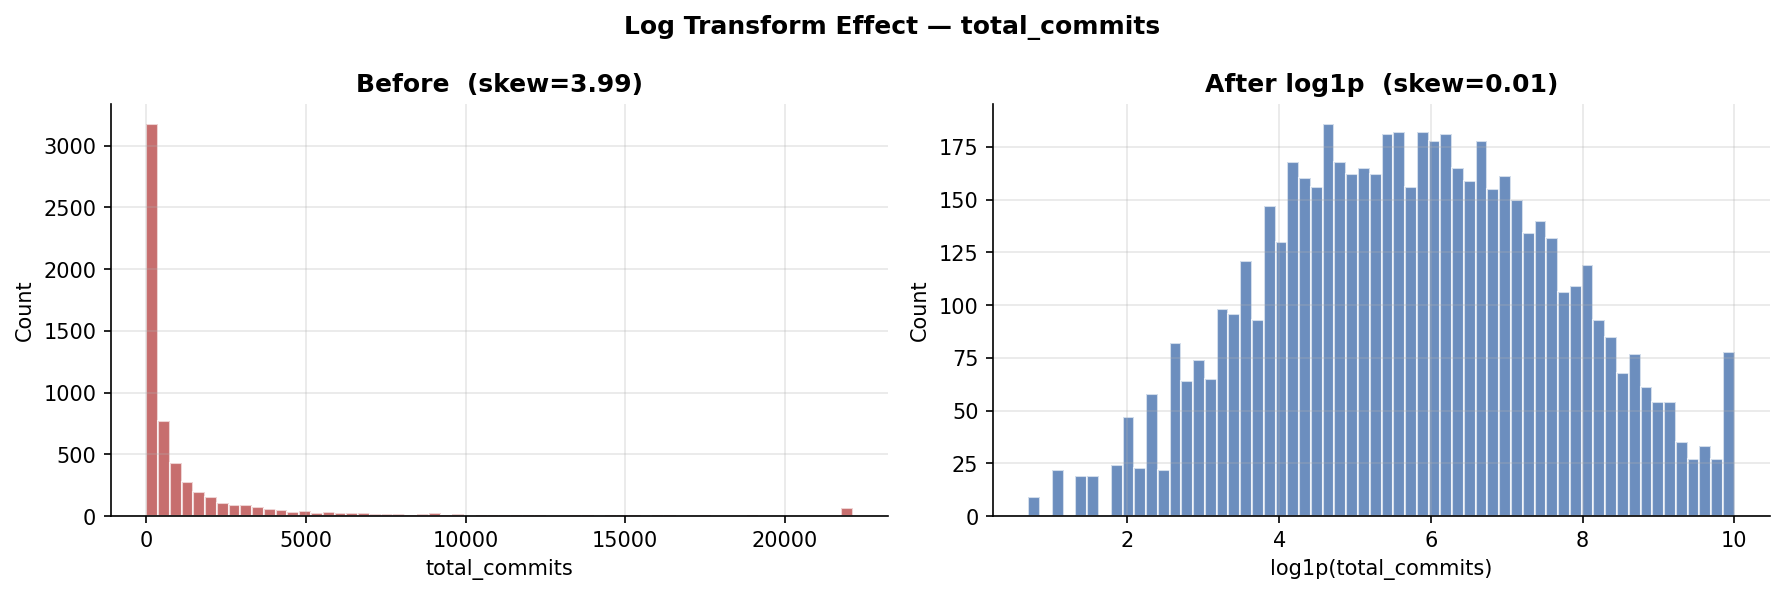


✓ Log transforms done — 5 new columns created


In [4]:
# ── CELL 4: Feature Group 1 — Log Transforms ─────────────────────────────
# WHY: EDA showed total_commits, stars, PRs, issues are power-law skewed
# (skewness > 2). A Random Forest can handle this, but log-transforms
# create a better numeric representation — distances between values
# become more meaningful (100 vs 200 commits ≠ 10000 vs 10100 commits)
# log1p(x) = log(x+1) — the +1 handles zeros safely

df_fe = df.copy()

skewed_cols = {
    'total_commits'         : 'Proof-of-Work',
    'stars_received'        : 'Proof-of-Work',
    'pull_requests_merged'  : 'Proof-of-Work',
    'issues_closed'         : 'Proof-of-Work',
    'total_repos'           : 'Proof-of-Work',
}

print("Applying log1p() transforms:")
print(f"  {'Column':<30} {'Before skew':>12}  {'After skew':>12}  {'DNA Dimension'}")
print("  " + "─"*70)

for col, dim in skewed_cols.items():
    if col not in df_fe.columns:
        continue
    before_skew = df_fe[col].skew()
    new_col     = f'log_{col}'
    df_fe[new_col] = np.log1p(df_fe[col])
    after_skew  = df_fe[new_col].skew()
    improvement = "✓ fixed" if abs(after_skew) < 1.0 else "~ improved"
    print(f"  {col:<30} {before_skew:>12.3f}  "
          f"{after_skew:>12.3f}  {dim}  {improvement}")

# Quick visualisation — before vs after for total_commits
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Log Transform Effect — total_commits',
             fontsize=12, fontweight='bold')

axes[0].hist(df_fe['total_commits'], bins=60,
             color='#B03030', alpha=0.7, edgecolor='white')
axes[0].set_title(f'Before  (skew={df_fe["total_commits"].skew():.2f})',
                  fontweight='bold')
axes[0].set_xlabel('total_commits')
axes[0].set_ylabel('Count')

axes[1].hist(df_fe['log_total_commits'], bins=60,
             color='#2E5FA3', alpha=0.7, edgecolor='white')
axes[1].set_title(f'After log1p  '
                  f'(skew={df_fe["log_total_commits"].skew():.2f})',
                  fontweight='bold')
axes[1].set_xlabel('log1p(total_commits)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('fe_01_log_transforms.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✓ Log transforms done — 5 new columns created")

Creating rate / velocity features:
  commit_velocity       = total_commits / (years_active × 52)
  recency_score         = commits_last_90d / total_commits
  repos_per_year        = total_repos / years_active
  pr_merge_rate         = merged_PRs / (merged_PRs + issues + 1)


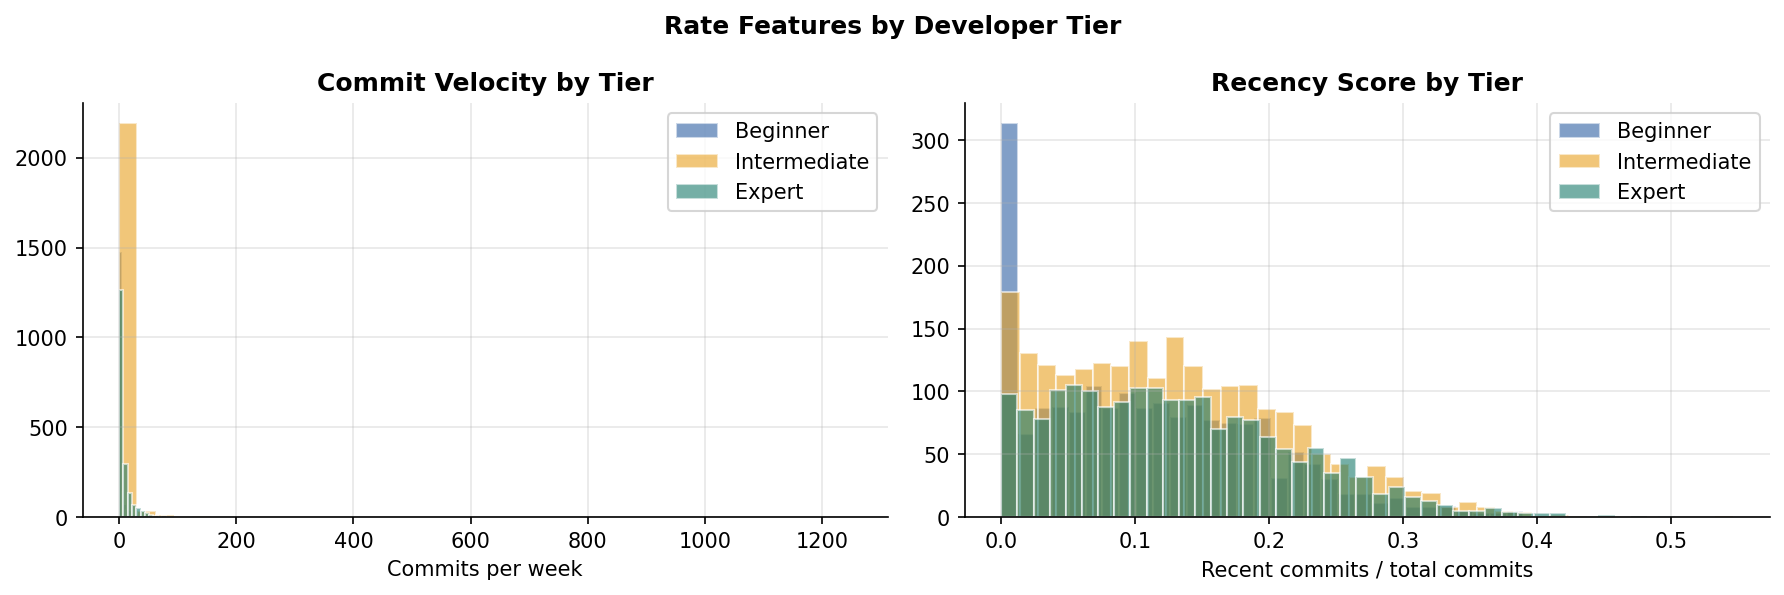


✓ Rate features done — 4 new columns created


In [5]:
# ── CELL 5: Feature Group 2 — Rate Features ──────────────────────────────
# WHY: Raw counts are biased by account age.
# A developer with 500 commits in 1 year >> one with 500 in 10 years.
# Rate features remove this age bias and measure VELOCITY not volume.

print("Creating rate / velocity features:")

# ── Commit Velocity [Proof-of-Work] ──────────────────────────────────────
# commits per active week — pure execution rate
df_fe['commit_velocity'] = (
    df_fe['total_commits'] /
    (df_fe['years_active'] * 52 + 1)
).round(4)
print(f"  commit_velocity       = total_commits / (years_active × 52)")

# ── Activity Recency Score [Proof-of-Work] ───────────────────────────────
# what fraction of all commits happened in the last 90 days?
# near 0 = mostly old activity,  near 1 = still actively coding
df_fe['recency_score'] = (
    df_fe['commits_last_90d'] /
    (df_fe['total_commits'] + 1)
).round(4)
print(f"  recency_score         = commits_last_90d / total_commits")

# ── Repos Per Year [Proof-of-Work] ───────────────────────────────────────
# delivery cadence — how fast does this dev ship projects?
df_fe['repos_per_year'] = (
    df_fe['total_repos'] /
    (df_fe['years_active'] + 1)
).round(4)
print(f"  repos_per_year        = total_repos / years_active")

# ── PR Merge Rate [Proof-of-Work] ────────────────────────────────────────
# merged PRs as fraction of total delivery activity
# high = code gets accepted, low = lots of issues, few merges
df_fe['pr_merge_rate'] = (
    df_fe['pull_requests_merged'] /
    (df_fe['pull_requests_merged'] + df_fe['issues_closed'] + 1)
).round(4)
print(f"  pr_merge_rate         = merged_PRs / (merged_PRs + issues + 1)")

# ── Visualise — rate features by tier ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Rate Features by Developer Tier',
             fontsize=12, fontweight='bold')

for tier in [0, 1, 2]:
    sub = df_fe[df_fe['developer_tier'] == tier]
    axes[0].hist(sub['commit_velocity'], bins=40, alpha=0.6,
                 color=TIER_COLORS[tier], label=TIER_NAMES[tier],
                 edgecolor='white')
    axes[1].hist(sub['recency_score'], bins=40, alpha=0.6,
                 color=TIER_COLORS[tier], label=TIER_NAMES[tier],
                 edgecolor='white')

axes[0].set_title('Commit Velocity by Tier', fontweight='bold')
axes[0].set_xlabel('Commits per week')
axes[0].legend()
axes[1].set_title('Recency Score by Tier', fontweight='bold')
axes[1].set_xlabel('Recent commits / total commits')
axes[1].legend()

plt.tight_layout()
plt.savefig('fe_02_rate_features.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✓ Rate features done — 4 new columns created")

Creating quality composite features:
  execution_quality = 0.40×tests + 0.30×readme + 0.30×CI
  language_count    = count of unique languages in languages_used
  impact_weight     = log(stars+1) × log(repos+1)
  profile_completeness = sum(has_bio + has_company + has_location + has_blog)


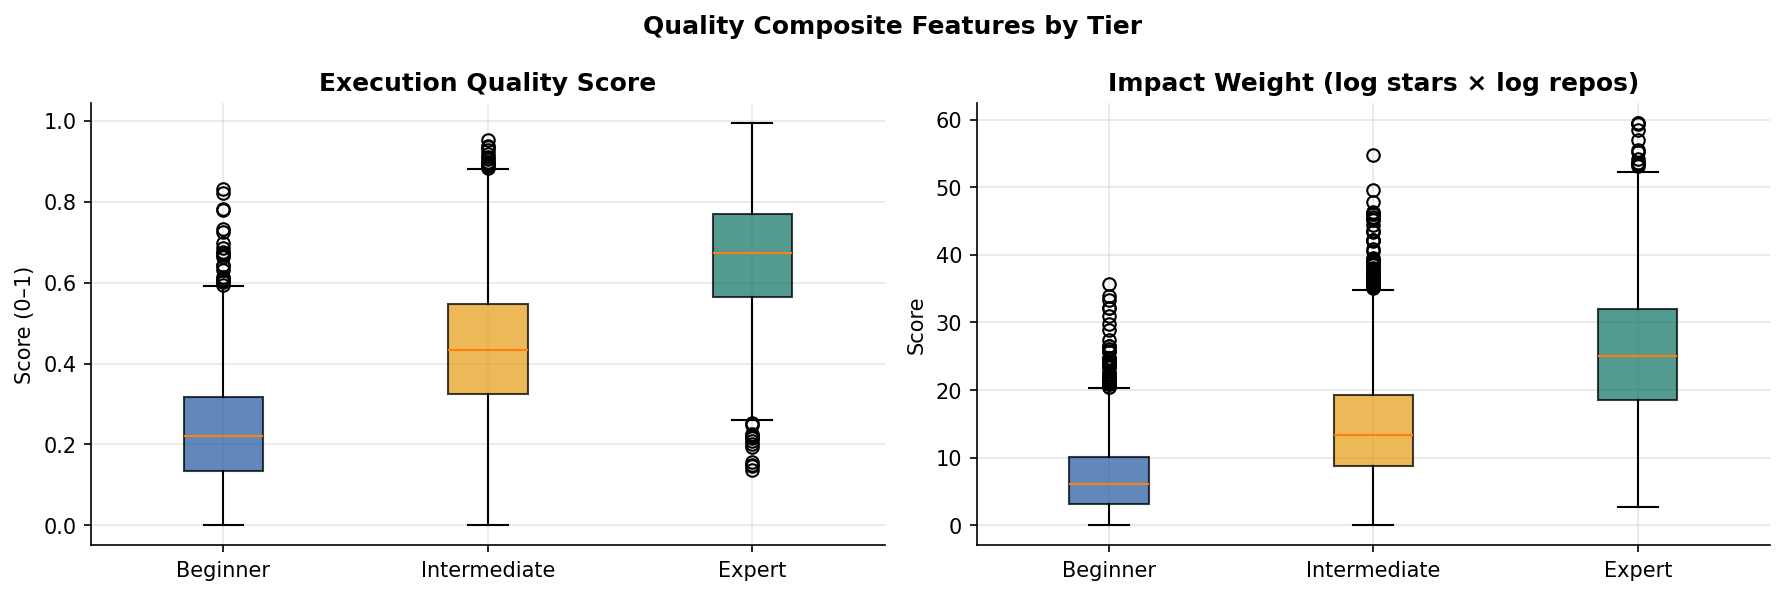


✓ Quality composite features done — 4 new columns created


In [6]:
# ── CELL 6: Feature Group 3 — Quality Composite Features ─────────────────
# WHY: Individual quality signals (readme, tests, CI) each measure one habit.
# A composite score measures the OVERALL professional maturity pattern.
# The weights come from domain knowledge — tests matter most (0.40)
# because they show engineering discipline, not just habit.

print("Creating quality composite features:")

# ── Execution Quality Score [Execution Pattern] ───────────────────────────
# Weighted combination of 3 professional coding habits
# Tests 40% + README 30% + CI 30% = professional maturity index
df_fe['execution_quality'] = (
    0.40 * df_fe['has_tests_pct'] +
    0.30 * df_fe['has_readme_pct'] +
    0.30 * df_fe['has_ci_pct']
).round(4)
print(f"  execution_quality = 0.40×tests + 0.30×readme + 0.30×CI")

# ── Language Count [Skill Genome] ────────────────────────────────────────
# number of distinct languages used — breadth signal
if 'language_count' not in df_fe.columns:
    df_fe['language_count'] = df_fe['languages_used'].apply(
        lambda x: len(str(x).split(','))
    )
print(f"  language_count    = count of unique languages in languages_used")

# ── Impact Weight [Thinking Blueprint] ───────────────────────────────────
# Interaction term: log(stars) × log(repos)
# WHY: A dev with many stars AND many repos has broader real-world impact
# than one with stars on a single viral project
df_fe['impact_weight'] = (
    np.log1p(df_fe['stars_received']) *
    np.log1p(df_fe['total_repos'])
).round(4)
print(f"  impact_weight     = log(stars+1) × log(repos+1)")

# ── Profile Completeness [Thinking Blueprint] ─────────────────────────────
# Sum of binary profile signals — measures professional self-presentation
# bio + company + location + blog → 0 to 4
if 'profile_completeness' not in df_fe.columns:
    bio_cols = ['has_bio', 'has_company', 'has_location', 'has_blog']
    available_bio = [c for c in bio_cols if c in df_fe.columns]
    df_fe['profile_completeness'] = df_fe[available_bio].sum(axis=1)
    print(f"  profile_completeness = sum(has_bio + has_company + "
          f"has_location + has_blog)")

# ── Visualise execution quality by tier ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Quality Composite Features by Tier', fontsize=12,
             fontweight='bold')

tier_eq = [df_fe[df_fe['developer_tier']==t]['execution_quality'].values
           for t in [0,1,2]]
bp = axes[0].boxplot(tier_eq, patch_artist=True,
                     labels=['Beginner','Intermediate','Expert'])
for patch, tier in zip(bp['boxes'], [0,1,2]):
    patch.set_facecolor(TIER_COLORS[tier])
    patch.set_alpha(0.75)
axes[0].set_title('Execution Quality Score', fontweight='bold')
axes[0].set_ylabel('Score (0–1)')

tier_iw = [df_fe[df_fe['developer_tier']==t]['impact_weight'].values
           for t in [0,1,2]]
bp2 = axes[1].boxplot(tier_iw, patch_artist=True,
                      labels=['Beginner','Intermediate','Expert'])
for patch, tier in zip(bp2['boxes'], [0,1,2]):
    patch.set_facecolor(TIER_COLORS[tier])
    patch.set_alpha(0.75)
axes[1].set_title('Impact Weight (log stars × log repos)', fontweight='bold')
axes[1].set_ylabel('Score')

plt.tight_layout()
plt.savefig('fe_03_quality_features.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✓ Quality composite features done — 4 new columns created")

Creating growth and consistency features:
  growth_momentum   = commit_trend_slope / (years_active + 1)
  consistency_index = 1 / (1 + |decay_lambda|)
  → Score near 1.0 = very consistent developer
  → Score near 0.0 = erratic / dropped off


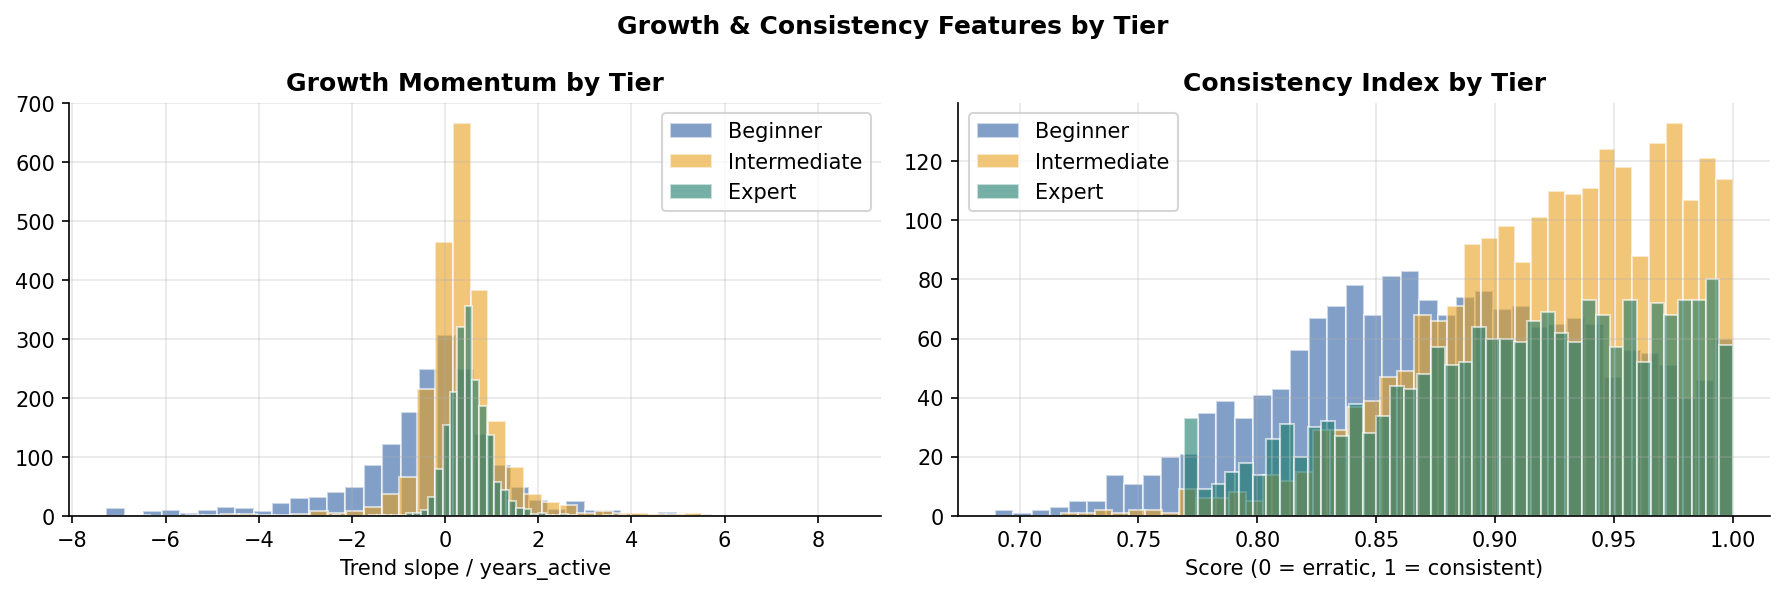


✓ Growth & consistency features done — 3 new columns created


In [7]:
# ── CELL 7: Feature Group 4 — Growth & Consistency Features ──────────────
# WHY: Raw trend_slope and decay_lambda are valid but unscaled.
# A slope of +2.0 means different things for a 1-year dev vs a 10-year dev.
# These features normalise the growth signals by career context.

print("Creating growth and consistency features:")

# ── Growth Momentum [Growth Signature] ───────────────────────────────────
# commit_trend_slope normalised by career length
# A junior growing at slope=3.0 in year 1 > senior at slope=3.0 in year 10
df_fe['growth_momentum'] = (
    df_fe['commit_trend_slope'] /
    (df_fe['years_active'] + 1)
).round(4)
print(f"  growth_momentum   = commit_trend_slope / (years_active + 1)")

# ── Consistency Index [Growth Signature] ─────────────────────────────────
# Maps activity_decay_lambda to 0-1 scale
# lambda = 0 → score = 1.0 (perfectly consistent)
# lambda = 0.2 → score = 0.83 (slight decline)
# lambda = 0.5 → score = 0.67 (declining)
# Formula: 1 / (1 + |lambda|)
df_fe['consistency_index'] = (
    1 / (1 + np.abs(df_fe['activity_decay_lambda']))
).round(4)
print(f"  consistency_index = 1 / (1 + |decay_lambda|)")
print(f"  → Score near 1.0 = very consistent developer")
print(f"  → Score near 0.0 = erratic / dropped off")

# ── Encode primary_language ───────────────────────────────────────────────
# RF can't read strings — encode primary_language as integer
if 'primary_language_encoded' not in df_fe.columns:
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    df_fe['primary_language_encoded'] = le.fit_transform(
        df_fe['primary_language'].astype(str)
    )
    print(f"  primary_language_encoded = LabelEncoder on primary_language")
    print(f"    ({df_fe['primary_language'].nunique()} unique languages → integers)")

# ── Visualise consistency index by tier ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Growth & Consistency Features by Tier',
             fontsize=12, fontweight='bold')

for tier in [0, 1, 2]:
    sub = df_fe[df_fe['developer_tier'] == tier]
    axes[0].hist(sub['growth_momentum'], bins=40, alpha=0.6,
                 color=TIER_COLORS[tier], label=TIER_NAMES[tier],
                 edgecolor='white')
    axes[1].hist(sub['consistency_index'], bins=40, alpha=0.6,
                 color=TIER_COLORS[tier], label=TIER_NAMES[tier],
                 edgecolor='white')

axes[0].set_title('Growth Momentum by Tier', fontweight='bold')
axes[0].set_xlabel('Trend slope / years_active')
axes[0].legend()

axes[1].set_title('Consistency Index by Tier', fontweight='bold')
axes[1].set_xlabel('Score (0 = erratic, 1 = consistent)')
axes[1].legend()

plt.tight_layout()
plt.savefig('fe_04_growth_features.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✓ Growth & consistency features done — 3 new columns created")

In [8]:
# ── CELL 8: Complete feature inventory — all engineered columns ───────────
# Document every feature created so far before selecting the final set

all_engineered = [
    # Group 1 — Log transforms
    ('log_total_commits',         'Log of total commits',              'Proof-of-Work'),
    ('log_stars_received',        'Log of stars received',             'Proof-of-Work'),
    ('log_pull_requests_merged',  'Log of merged pull requests',       'Proof-of-Work'),
    ('log_issues_closed',         'Log of closed issues',              'Proof-of-Work'),
    ('log_total_repos',           'Log of repo count',                 'Proof-of-Work'),
    # Group 2 — Rate features
    ('commit_velocity',           'Commits per active week',           'Proof-of-Work'),
    ('recency_score',             'Recent vs all-time commits',        'Proof-of-Work'),
    ('repos_per_year',            'Repos delivered per year',          'Proof-of-Work'),
    ('pr_merge_rate',             'Merged PRs / total activity',       'Proof-of-Work'),
    # Group 3 — Quality composites
    ('execution_quality',         'Weighted tests+readme+CI score',    'Execution Pattern'),
    ('language_count',            'Number of distinct languages',      'Skill Genome'),
    ('impact_weight',             'log(stars) × log(repos)',           'Thinking Blueprint'),
    ('profile_completeness',      'Bio+company+location+blog sum',     'Thinking Blueprint'),
    ('primary_language_encoded',  'Primary language as integer',       'Skill Genome'),
    # Group 4 — Growth & consistency
    ('growth_momentum',           'Trend slope / years active',        'Growth Signature'),
    ('consistency_index',         '1 / (1 + |decay_lambda|)',          'Growth Signature'),
]

print("=" * 70)
print("  COMPLETE FEATURE ENGINEERING SUMMARY")
print("=" * 70)
print(f"\n  Original columns in processed dataset : {len(df_raw.columns)}")
print(f"  New features engineered               : {len(all_engineered)}")
print(f"  Total columns now                     : {len(df_fe.columns)}")
print(f"\n  All engineered features:")
print(f"  {'Feature':<35} {'Interpretation':<40} {'DNA Dimension'}")
print(f"  {'─'*35} {'─'*40} {'─'*20}")
for feat, interp, dim in all_engineered:
    status = "✓" if feat in df_fe.columns else "✗ MISSING"
    print(f"  {status} {feat:<33} {interp:<40} {dim}")

print(f"\n  Feature stats (new features only):")
new_feat_names = [f[0] for f in all_engineered if f[0] in df_fe.columns]
for feat in new_feat_names:
    s = df_fe[feat]
    print(f"  {feat:<35} "
          f"mean={s.mean():>8.3f}  "
          f"std={s.std():>8.3f}  "
          f"skew={s.skew():>6.2f}")

  COMPLETE FEATURE ENGINEERING SUMMARY

  Original columns in processed dataset : 30
  New features engineered               : 16
  Total columns now                     : 45

  All engineered features:
  Feature                             Interpretation                           DNA Dimension
  ─────────────────────────────────── ──────────────────────────────────────── ────────────────────
  ✓ log_total_commits                 Log of total commits                     Proof-of-Work
  ✓ log_stars_received                Log of stars received                    Proof-of-Work
  ✓ log_pull_requests_merged          Log of merged pull requests              Proof-of-Work
  ✓ log_issues_closed                 Log of closed issues                     Proof-of-Work
  ✓ log_total_repos                   Log of repo count                        Proof-of-Work
  ✓ commit_velocity                   Commits per active week                  Proof-of-Work
  ✓ recency_score                     Recent v

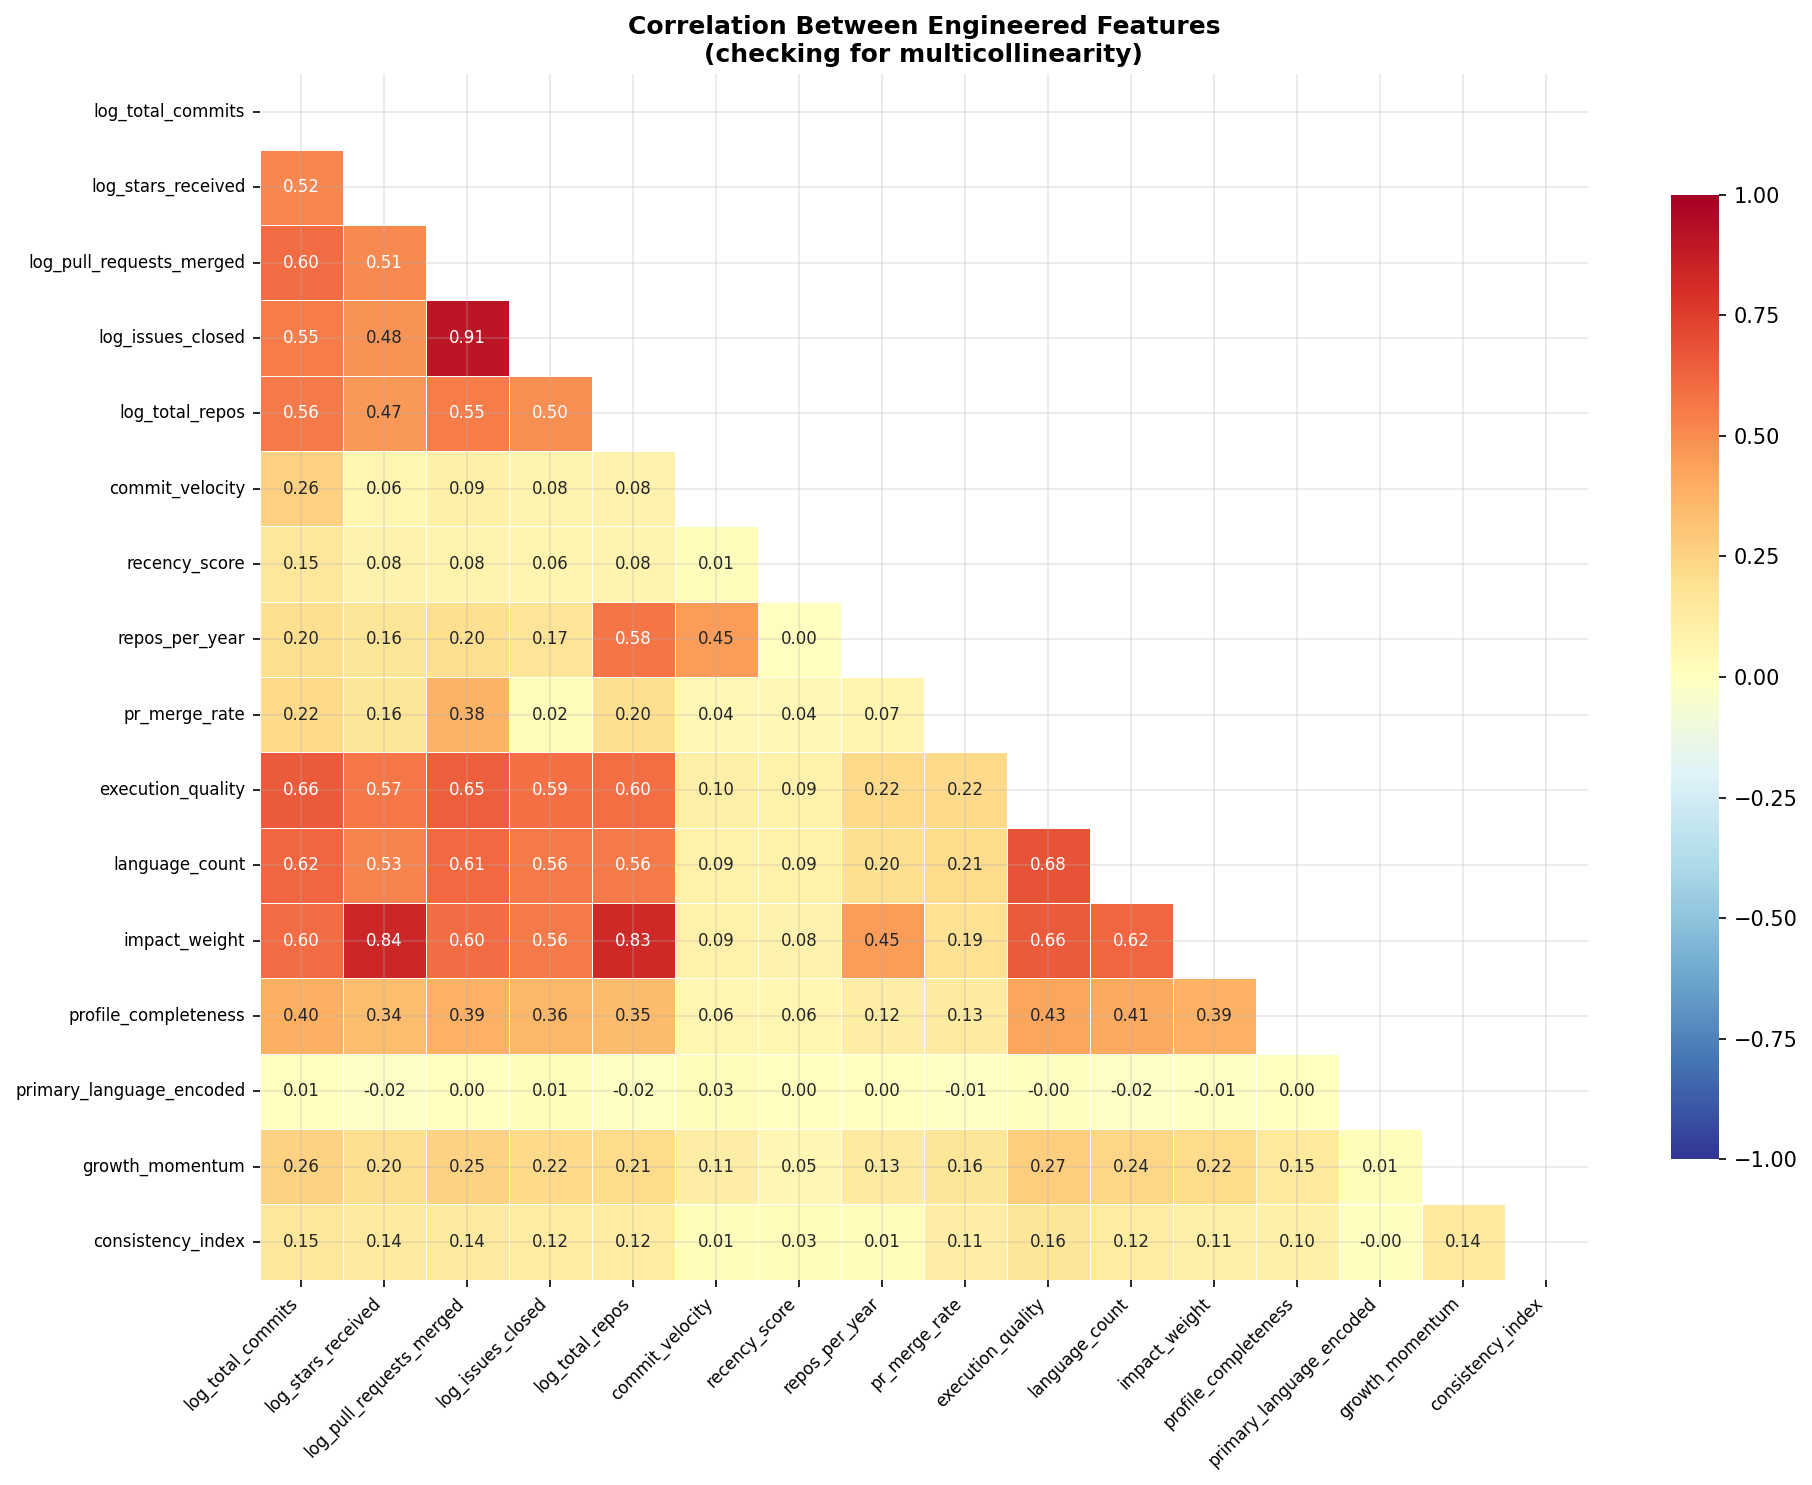

High correlation pairs in engineered features (|r| > 0.75):
  log_stars_received                  ↔  impact_weight                       r=0.836
  log_pull_requests_merged            ↔  log_issues_closed                   r=0.911
  log_total_repos                     ↔  impact_weight                       r=0.832

  Decision: any pair with |r| > 0.90 — drop the less interpretable one


In [9]:
# ── CELL 9: Correlation check — are any new features redundant? ───────────
# Before finalising the feature set, check if any engineered features
# are too correlated with each other (|r| > 0.90 = multicollinearity)

new_feat_names = [f[0] for f in all_engineered if f[0] in df_fe.columns]

corr_new = df_fe[new_feat_names].corr()

plt.figure(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_new, dtype=bool))
sns.heatmap(
    corr_new, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlBu_r', center=0, vmin=-1, vmax=1,
    annot_kws={'size': 8}, linewidths=0.4,
    cbar_kws={'shrink': 0.8}
)
plt.title('Correlation Between Engineered Features\n'
          '(checking for multicollinearity)',
          fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('fe_05_feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# Print high correlations
print("High correlation pairs in engineered features (|r| > 0.75):")
found = False
for i in range(len(corr_new.columns)):
    for j in range(i+1, len(corr_new.columns)):
        r = corr_new.iloc[i, j]
        if abs(r) > 0.75:
            print(f"  {corr_new.columns[i]:<35} ↔  "
                  f"{corr_new.columns[j]:<35} r={r:.3f}")
            found = True
if not found:
    print("  None found — no multicollinearity issues ✓")
print(f"\n  Decision: any pair with |r| > 0.90 — drop the less interpretable one")

In [10]:
# ── CELL 10: Final feature selection ─────────────────────────────────────
# Build the exact list of columns that will go into the model
# Document every drop decision — this goes in your LaTeX report

print("FEATURE SELECTION DECISIONS")
print("="*60)
print("\nDROPPED — with mathematical reason:")

dropped = {
    'developer_id'          : 'Text identifier — not numeric',
    'languages_used'        : 'Raw text — RF cannot parse strings',
    'primary_language'      : 'Replaced by primary_language_encoded',
    'developer_dna_score'   : '*** DATA LEAKAGE — IS the answer ***',
    'developer_tier'        : 'TARGET VARIABLE — goes into y not X',
    'account_age_days'      : 'Replaced by years_active (years is cleaner unit)',
    'total_commits'         : 'Replaced by log_total_commits (less skewed)',
    'commits_last_90d'      : 'Replaced by recency_score (relative metric)',
    'stars_received'        : 'Replaced by log_stars_received',
    'total_repos'           : 'Kept raw AND as log — both carry info',
    'pull_requests_merged'  : 'Replaced by log_pull_requests_merged',
    'issues_closed'         : 'Replaced by log_issues_closed',
}
for col, reason in dropped.items():
    print(f"  ✗ {col:<30} → {reason}")

# ── Final 28 features going into the model ────────────────────────────────
FINAL_FEATURES = [
    # ── Proof-of-Work (30% DDS weight) ────────────────────────────────
    'log_total_commits',            # de-skewed commit volume
    'log_stars_received',           # de-skewed impact signal
    'log_pull_requests_merged',     # de-skewed PR signal
    'log_issues_closed',            # de-skewed issue signal
    'log_total_repos',              # de-skewed repo count
    'commit_velocity',              # commits per week (rate)
    'recency_score',                # recent vs historical activity
    'repos_per_year',               # delivery cadence
    'pr_merge_rate',                # code acceptance rate

    # ── Skill Genome (25% DDS weight) ─────────────────────────────────
    'language_entropy',             # Shannon diversity of languages
    'language_count',               # number of distinct languages
    'framework_count',              # framework breadth
    'primary_language_encoded',     # dominant specialisation (encoded)

    # ── Execution Pattern (20% DDS weight) ────────────────────────────
    'has_readme_pct',               # documentation habit (raw)
    'has_tests_pct',                # test coverage habit (raw)
    'has_ci_pct',                   # CI/CD adoption (raw)
    'execution_quality',            # weighted composite habit score
    'commit_message_avg_len',       # communication quality signal

    # ── Thinking Blueprint (15% DDS weight) ───────────────────────────
    'fork_to_original_ratio',       # creator vs consumer ratio
    'languages_per_repo_avg',       # full-stack / systems thinking
    'impact_weight',                # log(stars) × log(repos) interaction
    'profile_completeness',         # professional self-presentation
    'avg_repo_description_len',     # architectural communication

    # ── Growth Signature (10% DDS weight) ─────────────────────────────
    'commit_trend_slope',           # raw trajectory
    'activity_decay_lambda',        # raw decay rate
    'years_active',                 # career length
    'growth_momentum',              # normalised trajectory
    'consistency_index',            # 1/(1+|lambda|) stability score
]

# Keep only columns that actually exist in the dataframe
available = [c for c in FINAL_FEATURES if c in df_fe.columns]
missing   = [c for c in FINAL_FEATURES if c not in df_fe.columns]

print(f"\nFINAL FEATURES SELECTED: {len(available)}")
print(f"\n  {'#':<4} {'Feature':<35} {'DNA Dimension'}")
print(f"  {'─'*4} {'─'*35} {'─'*20}")

dim_map = {}
for feat, interp, dim in all_engineered:
    dim_map[feat] = dim

for i, feat in enumerate(available, 1):
    dim = dim_map.get(feat, 'Original')
    print(f"  {i:02d}.  {feat:<35} {dim}")

if missing:
    print(f"\n  Missing (run earlier cells): {missing}")

X = df_fe[available].fillna(0)
y = df_fe['developer_tier']

print(f"\n✓ X shape : {X.shape}")
print(f"✓ y shape : {y.shape}")
print(f"✓ Target classes: 0=Beginner, 1=Intermediate, 2=Expert")

# Save available features list for model notebook
import json
with open('selected_features.json', 'w') as f:
    json.dump(available, f)
print(f"✓ Saved selected_features.json — model notebook will load this")

FEATURE SELECTION DECISIONS

DROPPED — with mathematical reason:
  ✗ developer_id                   → Text identifier — not numeric
  ✗ languages_used                 → Raw text — RF cannot parse strings
  ✗ primary_language               → Replaced by primary_language_encoded
  ✗ developer_dna_score            → *** DATA LEAKAGE — IS the answer ***
  ✗ developer_tier                 → TARGET VARIABLE — goes into y not X
  ✗ account_age_days               → Replaced by years_active (years is cleaner unit)
  ✗ total_commits                  → Replaced by log_total_commits (less skewed)
  ✗ commits_last_90d               → Replaced by recency_score (relative metric)
  ✗ stars_received                 → Replaced by log_stars_received
  ✗ total_repos                    → Kept raw AND as log — both carry info
  ✗ pull_requests_merged           → Replaced by log_pull_requests_merged
  ✗ issues_closed                  → Replaced by log_issues_closed

FINAL FEATURES SELECTED: 28

  #    Featur

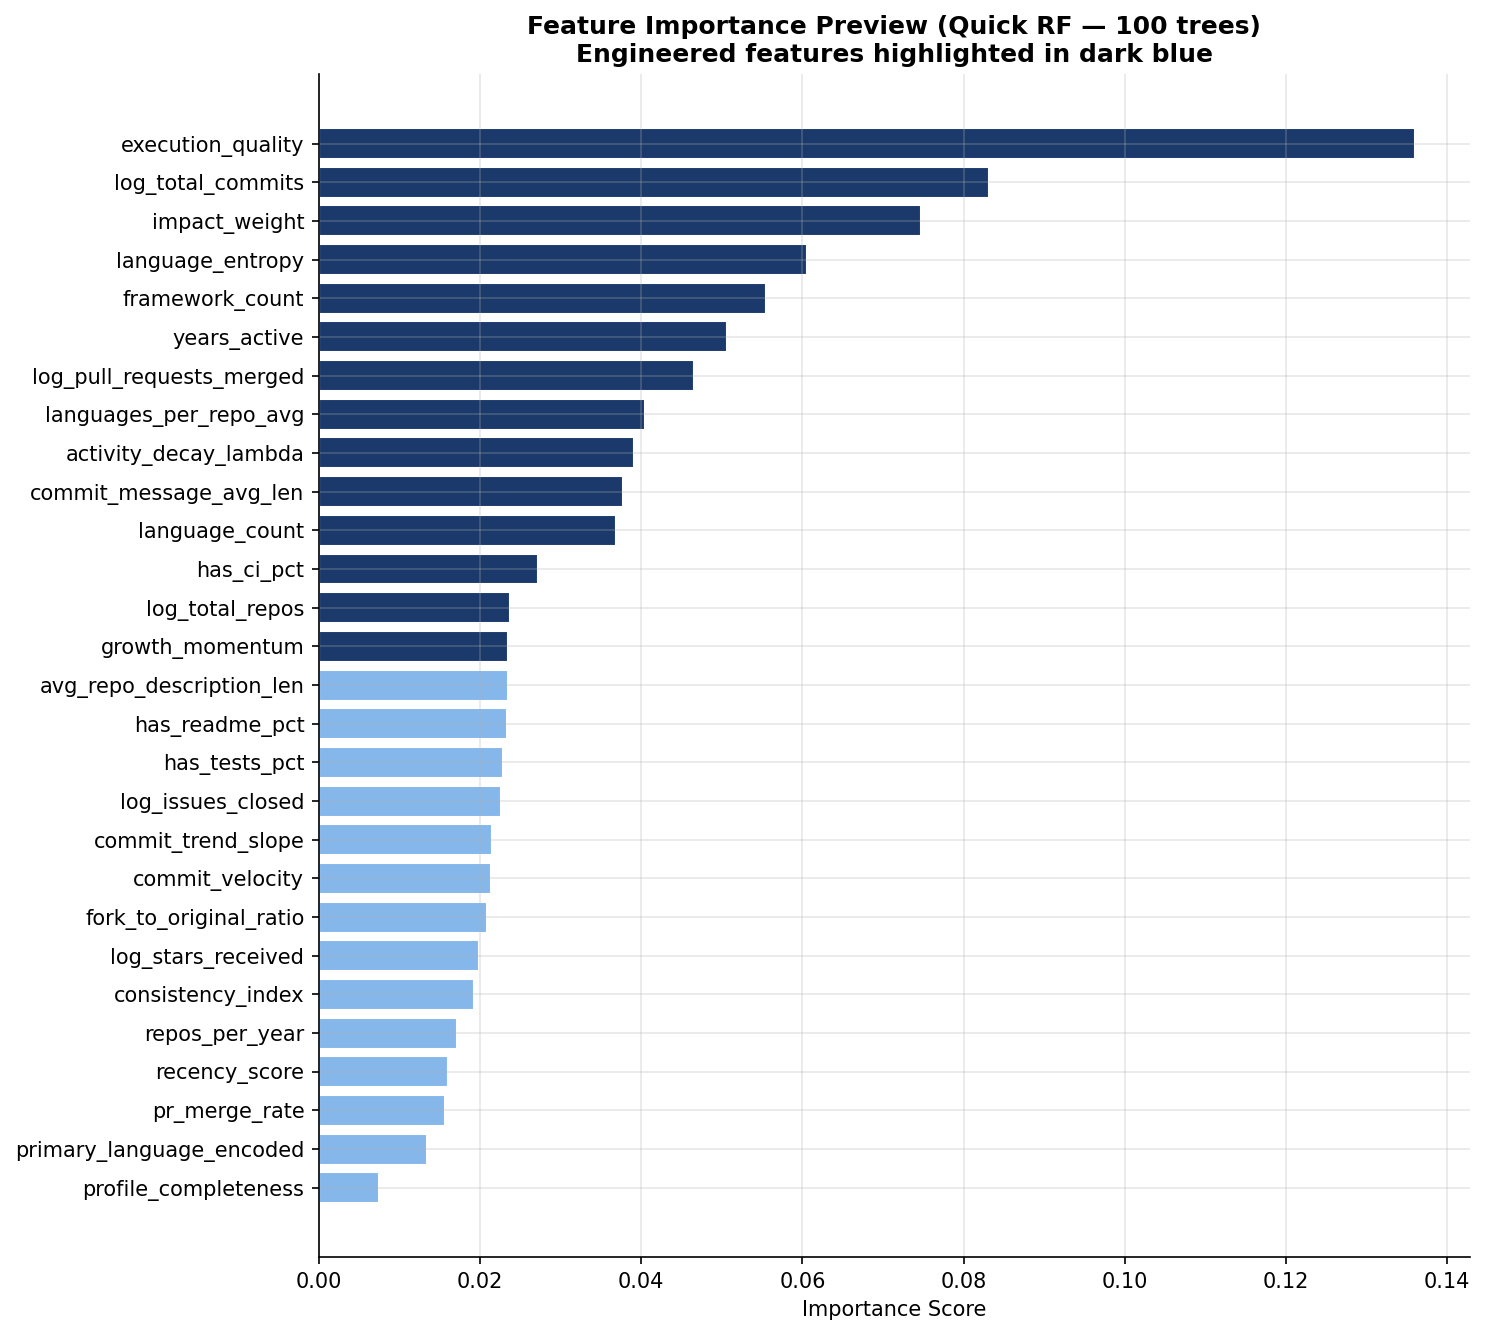

Top 10 most important features (preview):
  execution_quality                   0.1360  ← ENGINEERED
  log_total_commits                   0.0832  ← ENGINEERED
  impact_weight                       0.0748  ← ENGINEERED
  language_entropy                    0.0605
  framework_count                     0.0555
  years_active                        0.0506
  log_pull_requests_merged            0.0465  ← ENGINEERED
  languages_per_repo_avg              0.0405
  activity_decay_lambda               0.0391
  commit_message_avg_len              0.0377

  Note: Engineered features appearing in top 10 validates
  that feature engineering added real predictive value.


In [11]:
# ── CELL 11: Quick feature importance preview ─────────────────────────────
# Train a fast RF just to see which features carry the most signal


from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
sc   = StandardScaler()
Xts  = sc.fit_transform(X_tr)

rf_preview = RandomForestClassifier(
    n_estimators=100, random_state=42, n_jobs=-1
)
rf_preview.fit(Xts, y_tr)

imp_df = pd.DataFrame({
    'feature'   : available,
    'importance': rf_preview.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 9))
colors = ['#1B3A6B' if imp > imp_df['importance'].median()
          else '#85B7EB' for imp in imp_df['importance']]
plt.barh(imp_df['feature'], imp_df['importance'],
         color=colors, edgecolor='white')
plt.title('Feature Importance Preview (Quick RF — 100 trees)\n'
          'Engineered features highlighted in dark blue',
          fontsize=12, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('fe_06_importance_preview.png', dpi=150, bbox_inches='tight')
plt.show()

# Show top 10
print("Top 10 most important features (preview):")
top10 = imp_df.tail(10).iloc[::-1]
for _, row in top10.iterrows():
    is_engineered = row['feature'] not in df_raw.columns
    tag = "  ← ENGINEERED" if is_engineered else ""
    print(f"  {row['feature']:<35} {row['importance']:.4f}{tag}")

print(f"\n  Note: Engineered features appearing in top 10 validates")
print(f"  that feature engineering added real predictive value.")

In [12]:
# ── CELL 12: Save final dataset for Model notebook ────────────────────────
from google.colab import files
import os

# Save the full feature-engineered dataframe
df_fe.to_csv("github_dna_features.csv", index=False)
print(f"✓ Saved: github_dna_features.csv")
print(f"  Shape: {df_fe.shape}")
print(f"  This file is the INPUT for Notebook 3 (Model)")

# Also save just X and y for quick model loading
X.to_csv("X_features.csv", index=False)
y.to_csv("y_labels.csv", index=False, header=True)
print(f"✓ Saved: X_features.csv  ({X.shape})")
print(f"✓ Saved: y_labels.csv    ({y.shape})")

# Summary of what to upload to GitHub
print(f"\n── GitHub repo upload checklist ─────────────────────────────")
print(f"  /data/github_dna_features.csv     ← main output of this notebook")
print(f"  /data/X_features.csv              ← feature matrix")
print(f"  /data/y_labels.csv                ← target labels")
print(f"  /data/selected_features.json      ← feature names list")
print(f"  /figures/fe_01_log_transforms.png")
print(f"  /figures/fe_02_rate_features.png")
print(f"  /figures/fe_03_quality_features.png")
print(f"  /figures/fe_04_growth_features.png")
print(f"  /figures/fe_05_feature_correlation.png")
print(f"  /figures/fe_06_importance_preview.png")
print(f"\nDownloading all files...")

downloads = [
    "github_dna_features.csv",
    "X_features.csv",
    "y_labels.csv",
    "selected_features.json",
    "fe_01_log_transforms.png",
    "fe_02_rate_features.png",
    "fe_03_quality_features.png",
    "fe_04_growth_features.png",
    "fe_05_feature_correlation.png",
    "fe_06_importance_preview.png",
]

for fname in downloads:
    if os.path.exists(fname):
        files.download(fname)
        print(f"  ✓ {fname}")
    else:
        print(f"  ✗ {fname} — re-run the relevant cell first")

✓ Saved: github_dna_features.csv
  Shape: (6000, 45)
  This file is the INPUT for Notebook 3 (Model)
✓ Saved: X_features.csv  ((6000, 28))
✓ Saved: y_labels.csv    ((6000,))

── GitHub repo upload checklist ─────────────────────────────
  /data/github_dna_features.csv     ← main output of this notebook
  /data/X_features.csv              ← feature matrix
  /data/y_labels.csv                ← target labels
  /data/selected_features.json      ← feature names list
  /figures/fe_01_log_transforms.png
  /figures/fe_02_rate_features.png
  /figures/fe_03_quality_features.png
  /figures/fe_04_growth_features.png
  /figures/fe_05_feature_correlation.png
  /figures/fe_06_importance_preview.png



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✓ github_dna_features.csv


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  ✓ fe_05_feature_correlation.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✓ fe_06_importance_preview.png
